In [1]:
import numpy as np
import pandas as pd
import h5py
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator,LogLocator,NullFormatter)
from matplotlib.colors import LogNorm
import glob
import yaml
from astropy.cosmology import Planck15,z_at_value
from astropy import units as u
from scipy.interpolate import interp1d

In [3]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.sans-serif'] = ['Bitstream Vera Sans']
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['axes.unicode_minus'] = False

import seaborn as sns
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('colorblind')
colors=sns.color_palette('colorblind')
fs=30

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

In [5]:
import arviz as az

In [6]:
from gwdistributions.distributions.spin.effective import IsotropicUniformMagnitudeChiEffGivenComponentMass

/home/omkar.sridhar/.conda/envs/gppop-dev-spin2/lib/python3.9/site-packages/gwdistributions/transforms/location.py:10: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal.lal import GreenwichMeanSiderealTime as GMST


The pyseobnr package has failed to load, you will not be able to employ SEOBNRv5 approximants.


In [7]:
from gppop.core_m1m2z import Utils,Vt_Utils,Rates, Post_Proc_Utils

In [8]:
import os
os.getcwd()

'/home/omkar.sridhar/NU_project_BGP/bbh-subpopulations-scripts/examples/BGP_m1m2z'

In [9]:
run_dir = 'data/'
plot_dir = 'plots/'
if not(os.path.exists(plot_dir)):
    os.makedirs(plot_dir)

with open(run_dir + 'config.yaml', "r") as stream:
    config = yaml.full_load(stream)

mbins, zbins = np.array(config['mbins']),np.array(config['zbins'])

trace = az.from_netcdf('output/gppop_GWTC4_posterior_newbins3_kappa_corr_m1m2z.nc')

In [10]:
utils = Utils(mbins,zbins)

In [11]:
dm1 = utils.delta_logm1s(mbins)
dm2 = utils.delta_logm2s(mbins)
log_bin_centers = utils.generate_log_bin_centers()

In [12]:
N_samples = int(len(trace['posterior']['draw'])*len(trace['posterior']['chain']))
nbins_m = len(mbins)-1

nbins_z = len(zbins)-1

n_corr_samples = np.array([trace['posterior']['n_corr'].to_numpy()[:,:,i].reshape((N_samples,)) for i in range(len(log_bin_centers))]).T
n_corr_samples.shape

(18000, 2024)

In [13]:
pp_utils = Post_Proc_Utils(mbins,zbins)

# Convergence testing

In [14]:
with h5py.File('data/' + config['meta_file'],'r') as hf:
    gppop_data = hf['gppop_metadata']
    vt_means,vt_sigmas, wt_means, wt_sigmas = gppop_data['vt_means'][()], gppop_data['vt_sigmas'][()], gppop_data['wt_means'][()], gppop_data['wt_sigmas'][()]

In [15]:
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.sans-serif'] = ['Bitstream Vera Sans']
#matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['axes.unicode_minus'] = False

sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('colorblind')
colors=sns.color_palette('colorblind')

In [16]:
Neff = []
for this_n_corr in n_corr_samples:  
    denominator = np.sum((wt_sigmas*this_n_corr[None,:])**2, axis =-1)
    numerator = np.dot(wt_means, this_n_corr)**2
    Neff.append(min(numerator/denominator))


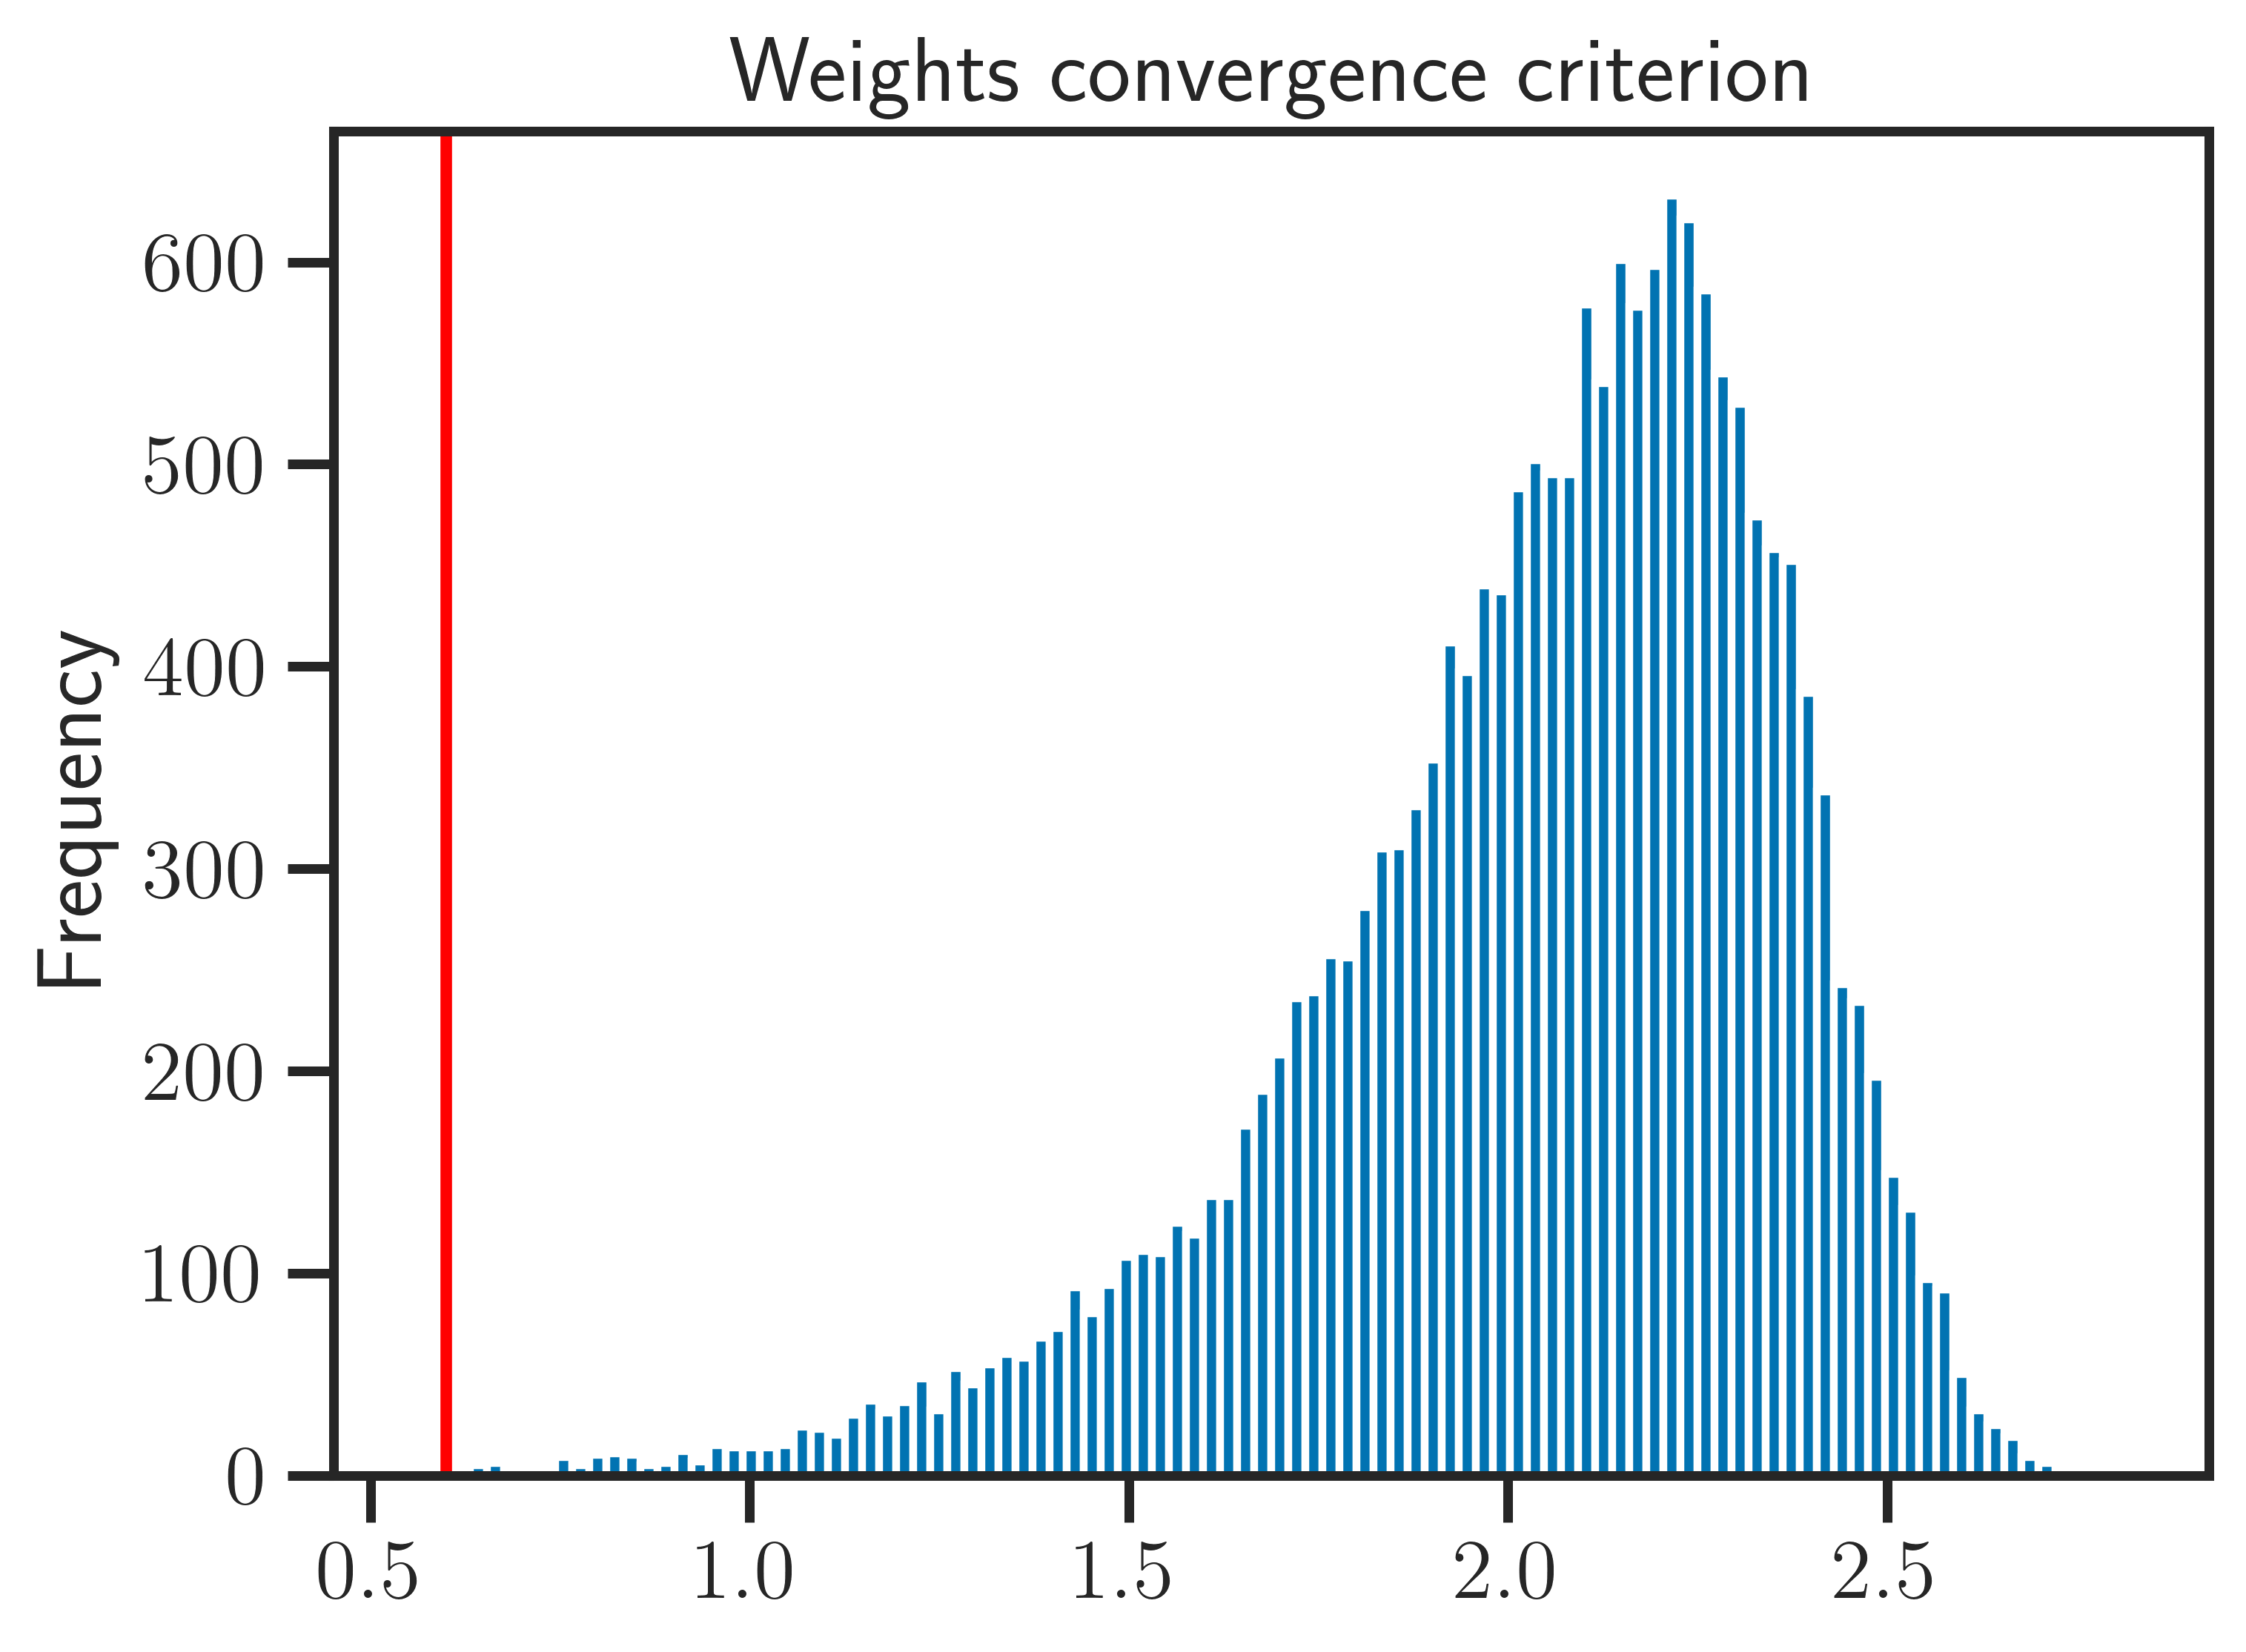

In [17]:
fig, ax = plt.subplots(1,dpi = 500, tight_layout = True)

ax.hist(np.log10(Neff), bins = 100)
ax.axvline(0.6, color = 'r')
#plt.show()

ax.set_title('Weights convergence criterion')

ax.set_ylabel('Frequency')

plt.show()

In [18]:
Neffarr = np.array(Neff)
np.where(np.log10(Neffarr) < 0.6)[0].shape

(2,)

In [19]:
n_corr_samples_copy = np.copy(n_corr_samples)
n_corr_samples_copy = np.delete(n_corr_samples_copy, np.where(np.log10(Neffarr) < 0.6)[0], 0)

In [20]:
n_corr_samples = np.copy(n_corr_samples_copy)
n_corr_samples.shape

(17998, 2024)

In [21]:
vt_sigmas += 1e-310

In [22]:
vt_cond = (np.sum((vt_means/vt_sigmas) ** 2) / np.dot(n_corr_samples, vt_means)) 
vt_cond

array([2063.09046307, 2046.74075663, 1896.28674717, ...,
       2365.92454489, 1821.13773913, 2491.83237826])

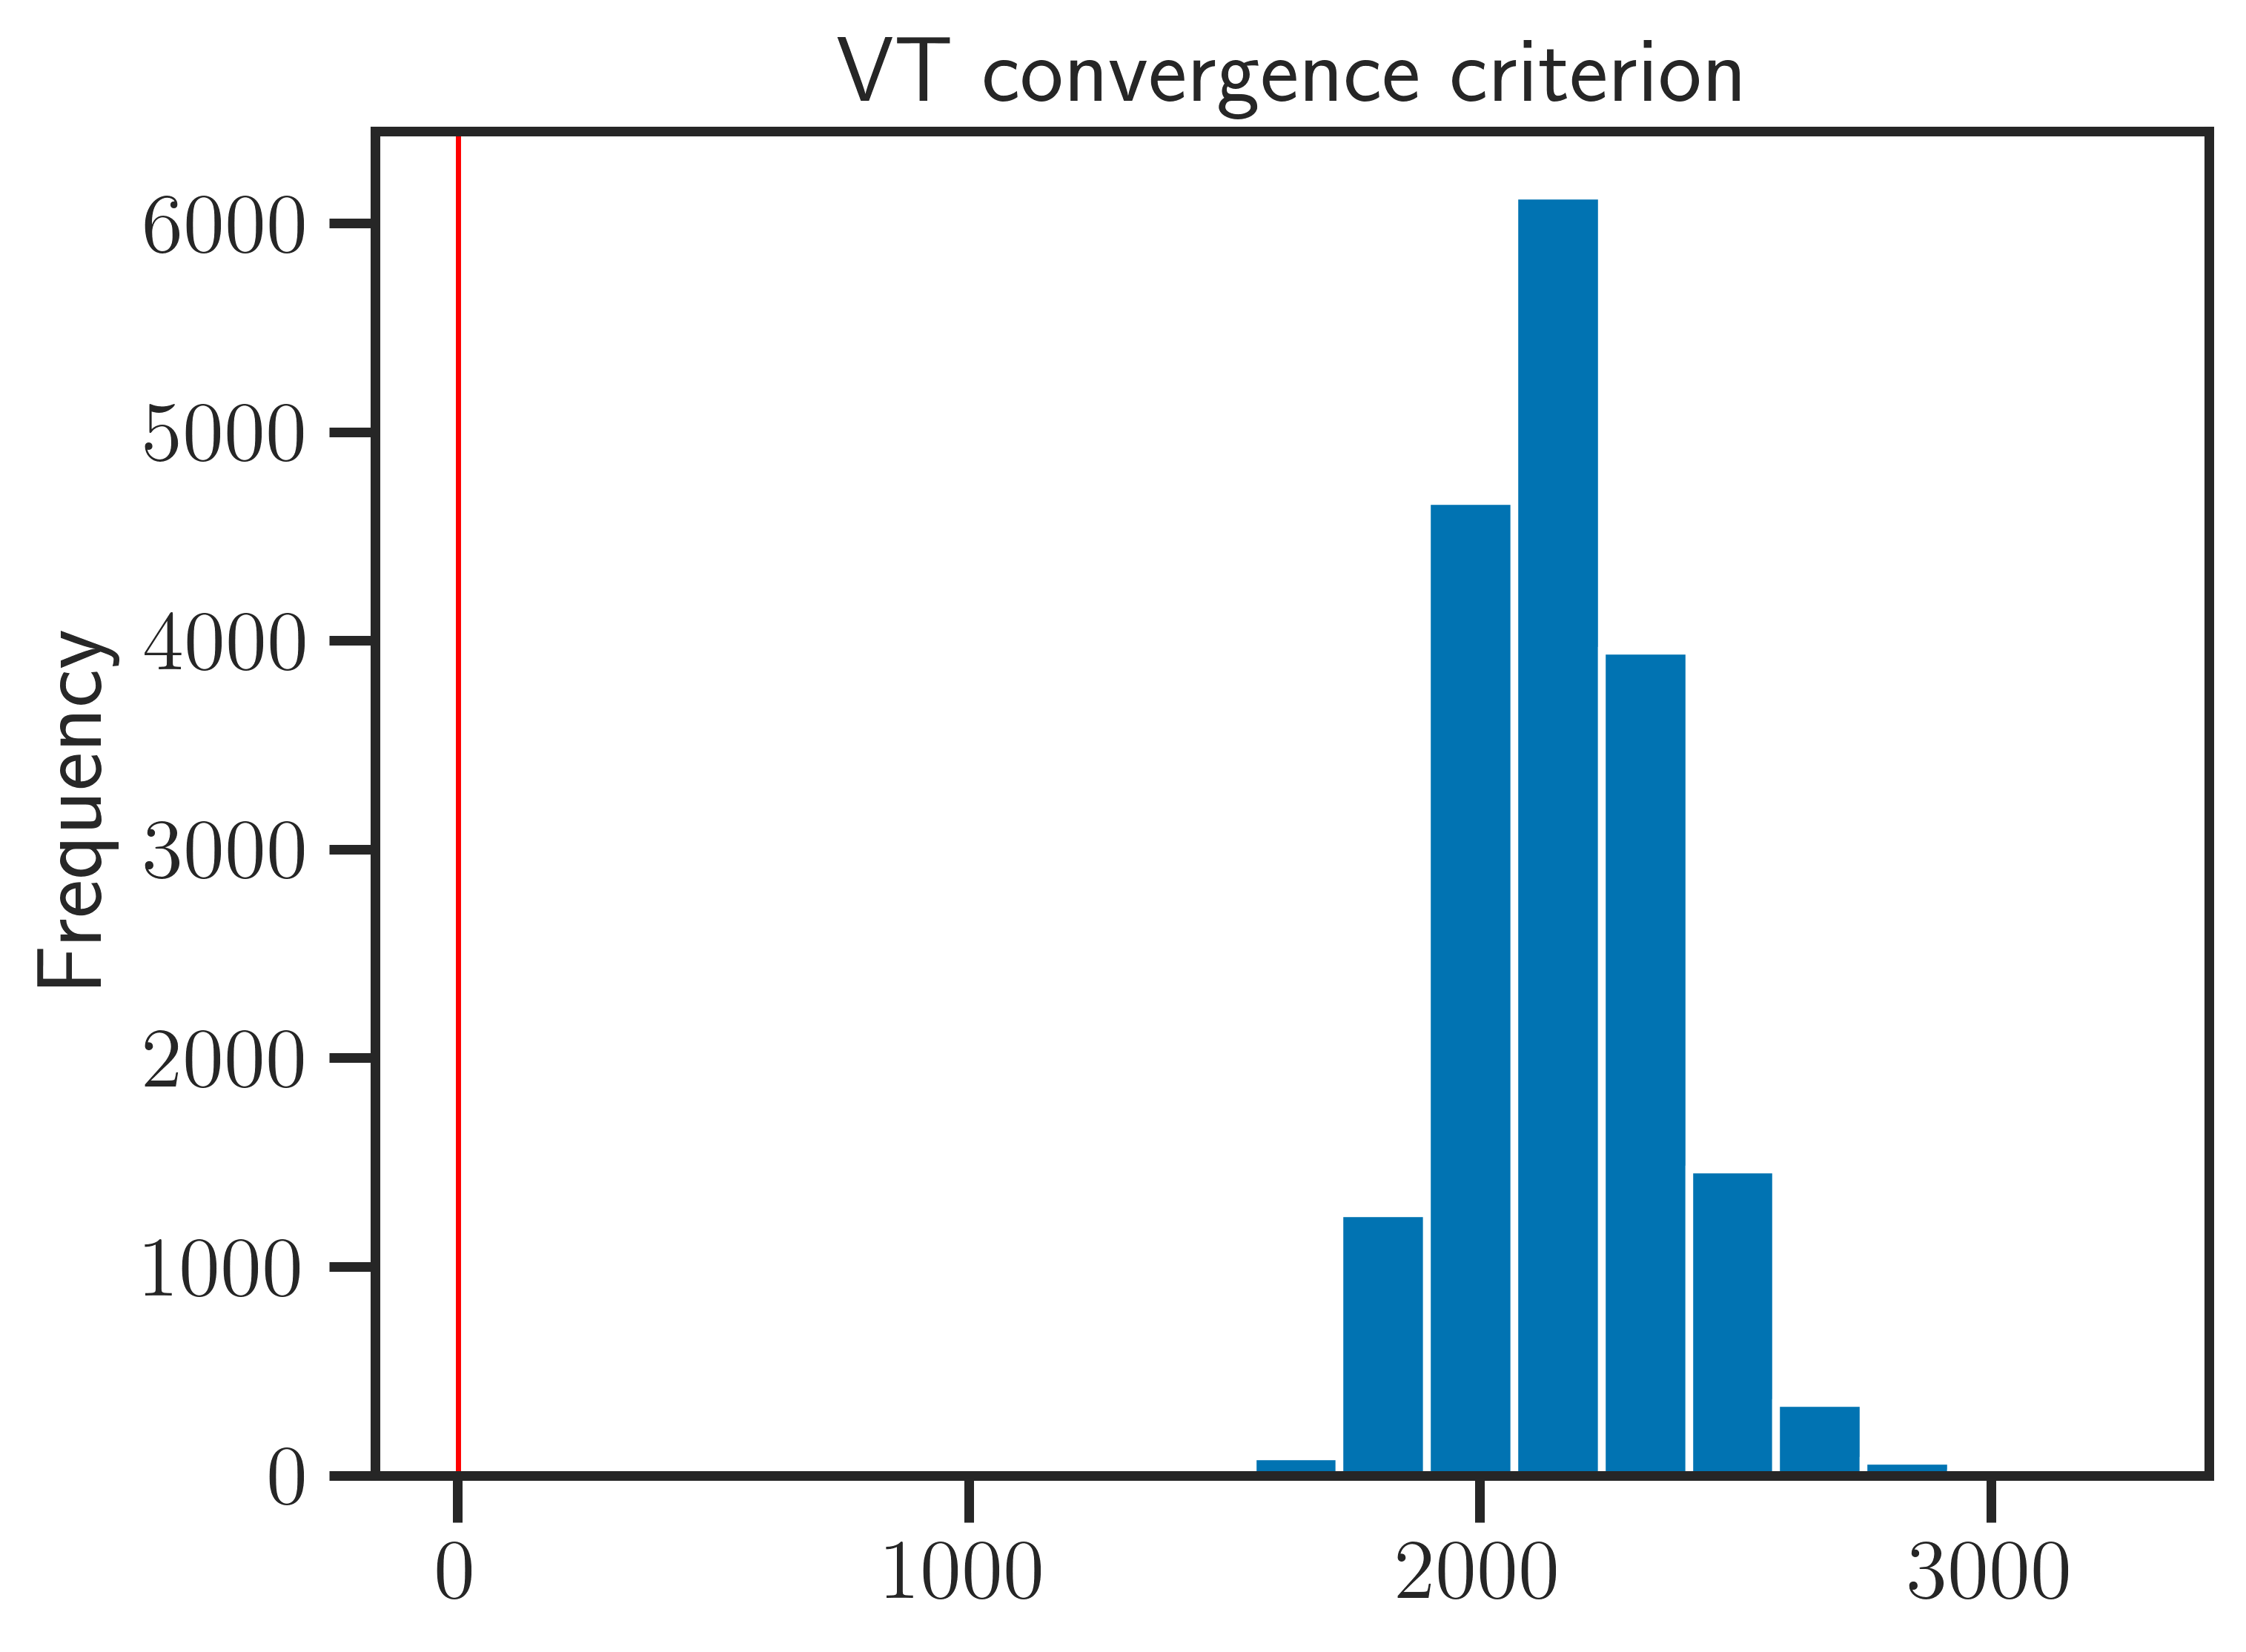

In [23]:
fig, ax = plt.subplots(1,dpi = 500, tight_layout = True)
ax.hist(vt_cond, bins = 10)
ax.axvline(2, color='r', linewidth=1)

ax.set_title('VT convergence criterion')

#plt.tight_layout()
ax.set_ylabel('Frequency')

plt.show()
#plt.savefig(plot_dir+'vt_cond_hist_case_6.pdf')

In [24]:
np.where(vt_cond < 2)

(array([], dtype=int64),)

# Conditional distributions

In [25]:
fs = 60

In [26]:
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.sans-serif'] = ['Bitstream Vera Sans']
#matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['axes.unicode_minus'] = False

sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('colorblind')
colors=sns.color_palette('colorblind')

In [27]:
mass1,Rpm1_corr1 = pp_utils.get_Rpm1_corr(n_corr_samples,dm2,mbins,mbins,log_bin_centers,0.1,1)
mass1,Rpm1_corr2 = pp_utils.get_Rpm1_corr(n_corr_samples,dm2,mbins,mbins,log_bin_centers,1,1.5)

In [28]:
fig, ax = plt.subplots(1,dpi = 500, tight_layout = True, figsize=(18*1.3,12*1.3))
matplotlib.rcParams.update({'font.size': 70})

Rp_m1=np.array(Rpm1_corr1)/np.trapz(Rpm1_corr1,mass1,axis=1)[:,None]
Rpm_5 = np.percentile(Rp_m1,q=5,axis=0)
Rpm_95 = np.percentile(Rp_m1,q=95,axis=0)
R_pm_med = np.percentile(Rp_m1,q=50,axis=0)
ax.fill_between(mass1,Rpm_5,Rpm_95,alpha=0.3,label=r'$z \in (0.1,1.0) $',color=colors[0])
ax.plot(mass1,R_pm_med,color=colors[0],linewidth=4.0)

Rp_m1=np.array(Rpm1_corr2)/np.trapz(Rpm1_corr2,mass1,axis=1)[:,None]
Rpm_5 = np.percentile(Rp_m1,q=5,axis=0)
Rpm_95 = np.percentile(Rp_m1,q=95,axis=0)
R_pm_med = np.percentile(Rp_m1,q=50,axis=0)
ax.fill_between(mass1,Rpm_5,Rpm_95,alpha=0.3,color=colors[1],label=r'$z \in (1.0,1.5)$')
ax.plot(mass1,R_pm_med,color=colors[1],linewidth=4.0)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(5,110)

#ax.set_ylim(1e-8,1)
ax.set_xlim(6,100)
ax.set_xlabel(r'$m_1~\left[M_{\odot}\right]$',fontsize=fs)
ax.set_ylabel(r'$p(m_1|z)$',fontsize=fs)
ax.tick_params(axis='both', which='major', labelsize=int(fs*0.8))
ax.tick_params(axis='both', which='minor', labelsize=int(fs*0.8))
ax.legend(fontsize=fs*0.58, framealpha=0.,ncol=1,loc='lower center')
ax.xaxis.label.set_size(fs)
ax.yaxis.label.set_size(fs)
fig.tight_layout()
ax.grid(linestyle=':',linewidth=3)
#fig.savefig(plot_dir+f'm1_chi_eff_{label}.pdf')
plt.show()

In [29]:
mass2,Rpm2_corr1 = pp_utils.get_Rpm2_corr(n_corr_samples,dm2,mbins,log_bin_centers,0.1,1)
mass2,Rpm2_corr2 = pp_utils.get_Rpm2_corr(n_corr_samples,dm2,mbins,log_bin_centers,1,1.5)

In [30]:
fig, ax = plt.subplots(1,dpi = 500, tight_layout = True, figsize=(18*1.3,12*1.3))
matplotlib.rcParams.update({'font.size': 70})

Rp_m2=np.array(Rpm2_corr1)/np.trapz(Rpm2_corr1,mass2,axis=1)[:,None]
Rpm_5 = np.percentile(Rp_m2,q=5,axis=0)
Rpm_95 = np.percentile(Rp_m2,q=95,axis=0)
R_pm_med = np.percentile(Rp_m2,q=50,axis=0)
ax.fill_between(mass2,Rpm_5,Rpm_95,alpha=0.3,label=r'$z \in (0.1,1.0) $',color=colors[0])
ax.plot(mass2,R_pm_med,color=colors[0],linewidth=4.0)

Rp_m2=np.array(Rpm2_corr2)/np.trapz(Rpm2_corr2,mass2,axis=1)[:,None]
Rpm_5 = np.percentile(Rp_m2,q=5,axis=0)
Rpm_95 = np.percentile(Rp_m2,q=95,axis=0)
R_pm_med = np.percentile(Rp_m2,q=50,axis=0)
ax.fill_between(mass2,Rpm_5,Rpm_95,alpha=0.3,color=colors[1],label=r'$z \in (1.0,1.5)$')
ax.plot(mass2,R_pm_med,color=colors[1],linewidth=4.0)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(5,110)

ax.set_ylim(1e-8,1)
ax.set_xlim(6,100)
ax.set_xlabel(r'$m_2~\left[M_{\odot}\right]$',fontsize=fs)
ax.set_ylabel(r'$p(m_2|z)$',fontsize=fs)
ax.tick_params(axis='both', which='major', labelsize=int(fs*0.8))
ax.tick_params(axis='both', which='minor', labelsize=int(fs*0.8))
ax.legend(fontsize=fs*0.58, framealpha=0.,ncol=1,loc='lower center')
ax.xaxis.label.set_size(fs)
ax.yaxis.label.set_size(fs)
fig.tight_layout()
ax.grid(linestyle=':',linewidth=3)
#fig.savefig(plot_dir+f'm1_chi_eff_{label}.pdf')
plt.show()